# 📊 Notebook 3: Live Dashboard & EWS Integration
**DigiHaz Doctoral Training Programme — Module 7: AI-Assisted IoT Development**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digihaz/digihaz-course-materials/blob/dev/module_07_iot_sensor_networks/topic_04/notebooks/03_dashboard_ews_integration.ipynb)

---

This notebook closes the loop between Module 7 (your IoT sensors) and Module 5 (the EWS). You will:

1. **Query the live Grafana dashboard's InfluxDB** to fetch your team's real sensor data
2. Apply the **ROC-optimised threshold** from Module 5 to trigger alerts
3. Build a **local matplotlib mirror** of the production Grafana dashboard
4. Discuss how this is the SENSORS layer of the EWS pipeline

If you don't have InfluxDB credentials, the notebook automatically falls back to synthetic data so you can still complete every exercise.

**For the live dashboard** (auto-refreshing, multi-site, publicly shareable), see `dashboard/SETUP_DASHBOARD.md` in the repo.

---

In [1]:
!pip install paho-mqtt influxdb-client --quiet

import os, json, time
from datetime import datetime, timezone, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PURPLE='#3D3780'; RED='#E63946'; ORANGE='#E07B24'
GREEN='#16A34A';  BLUE='#0A6EBD'; DARK='#1C1C2E'

print('✅ Libraries loaded')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 746.3/746.3 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.6/218.6 kB 9.2 MB/s eta 0:00:00
✅ Libraries loaded


---
## Part 1 — Configure InfluxDB Connection

**The workshop instructor will provide three values:**

- `INFLUX_URL` — URL of the workshop's InfluxDB Cloud
- `INFLUX_TOKEN` — a **read-only** token shared with students
- `INFLUX_BUCKET` — bucket name (usually `digihaz_sensors`)

Paste them below. If you don't have them yet, leave the placeholders — the notebook will use synthetic data instead.

🔒 **Security note:** Never paste a write-enabled or admin token into a notebook you might share. The instructor's token is read-only by design.

In [2]:
# ── PASTE YOUR INSTRUCTOR'S CREDENTIALS HERE ────────────────────────────
INFLUX_URL    = 'https://us-east-1-1.aws.cloud2.influxdata.com'
INFLUX_TOKEN  = 'PASTE_READ_ONLY_TOKEN_HERE'
INFLUX_ORG    = 'digihaz'
INFLUX_BUCKET = 'digihaz_sensors'
# ────────────────────────────────────────────────────────────────────────

USE_REAL_DATA = INFLUX_TOKEN != 'PASTE_READ_ONLY_TOKEN_HERE'

if USE_REAL_DATA:
    print('🌐 Will fetch LIVE data from InfluxDB')
    print(f'   URL: {INFLUX_URL}')
    print(f'   Bucket: {INFLUX_BUCKET}')
else:
    print('🔄 No credentials provided — using synthetic data')
    print('   (Notebook will still work end-to-end. Ask instructor for credentials.)')

🔄 No credentials provided — using synthetic data
   (Notebook will still work end-to-end. Ask instructor for credentials.)


---
## Part 2 — Fetch Sensor Data

The function below queries InfluxDB using the **Flux** query language. If credentials are missing, it generates a realistic synthetic dataset for 4 sites.

In [3]:
def fetch_from_influxdb(hours_back=24):
    from influxdb_client import InfluxDBClient
    client = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
    flux = f'''
        from(bucket: "{INFLUX_BUCKET}")
          |> range(start: -{hours_back}h)
          |> filter(fn: (r) => r._measurement == "sensors")
          |> filter(fn: (r) => r._field == "tilt_deg" or r._field == "press_hpa" or r._field == "soil_pct")
          |> pivot(rowKey:["_time", "site"], columnKey: ["_field"], valueColumn: "_value")
          |> keep(columns: ["_time", "site", "tilt_deg", "press_hpa", "soil_pct", "alert"])
    '''
    df = client.query_api().query_data_frame(flux)
    client.close()
    if isinstance(df, list):
        df = pd.concat(df, ignore_index=True)
    if len(df) == 0:
        return None
    df = df.rename(columns={'_time': 'time'})
    df['time'] = pd.to_datetime(df['time'])
    return df.sort_values(['site', 'time']).reset_index(drop=True)


def generate_synthetic(hours=24):
    np.random.seed(7)
    n = hours * 12
    end_time = datetime.now(timezone.utc)
    times = pd.date_range(end=end_time, periods=n, freq='5min')
    t = np.arange(n) * 5 / 60
    rows = []
    scenarios = {
        'site_alpha': dict(tilt=0.5+np.random.normal(0,0.2,n),
                           press=1013+1.5*np.sin(2*np.pi*t/12)+np.random.normal(0,0.4,n),
                           soil=35+5*np.sin(2*np.pi*t/24)+np.random.normal(0,1,n)),
        'site_beta':  dict(tilt=0.5+np.random.normal(0,0.2,n),
                           press=1013-10*np.exp(-((t-12)/4)**2)+np.random.normal(0,0.4,n),
                           soil=40+50*np.exp(-((t-14)/6)**2)+np.random.normal(0,1.5,n)),
        'site_gamma': dict(tilt=0.5+0.12*t+np.random.normal(0,0.2,n),
                           press=1013+1.5*np.sin(2*np.pi*t/12)+np.random.normal(0,0.4,n),
                           soil=40+30*np.exp(-((t-18)/8)**2)+np.random.normal(0,1,n)),
        'site_delta': dict(tilt=0.5+0.05*t+np.where(t>18,12*(1-np.exp(-(t-18))),0)+np.random.normal(0,0.3,n),
                           press=1013-12*np.exp(-((t-10)/5)**2)+np.random.normal(0,0.4,n),
                           soil=40+55*np.exp(-((t-14)/6)**2)+np.random.normal(0,1.5,n)),
    }
    for site, d in scenarios.items():
        d['soil'] = np.clip(d['soil'], 0, 100)
        for i in range(n):
            rows.append({
                'time': times[i], 'site': site,
                'tilt_deg': d['tilt'][i], 'press_hpa': d['press'][i],
                'soil_pct': d['soil'][i],
                'alert': 'RED' if (d['tilt'][i]>10 and d['soil'][i]>90)
                         else 'YELLOW' if (d['tilt'][i]>5 and d['soil'][i]>80)
                         else 'GREEN',
            })
    return pd.DataFrame(rows)


df = None
if USE_REAL_DATA:
    try:
        df = fetch_from_influxdb(hours_back=24)
        if df is None or len(df) == 0:
            print('⚠ InfluxDB returned no data for last 24h — using synthetic')
            df = None
    except Exception as e:
        print(f'⚠ InfluxDB query failed ({e}) — using synthetic')

if df is None:
    df = generate_synthetic(hours=24)
    print('✓ Generated synthetic dataset')
else:
    print('✅ Fetched live data from InfluxDB')

print(f'\nDataset: {len(df)} rows across {df["site"].nunique()} sites')
print(f'Time range: {df["time"].min()} → {df["time"].max()}')
print(f'Sites: {sorted(df["site"].unique())}')

✓ Generated synthetic dataset

Dataset: 1152 rows across 4 sites
Time range: 2026-06-23 05:14:25.449153+00:00 → 2026-06-24 05:09:25.449153+00:00
Sites: ['site_alpha', 'site_beta', 'site_delta', 'site_gamma']


---
## Part 3 — Local Mirror of the Grafana Dashboard

The instructor's Grafana dashboard at `dashboard/digihaz_dashboard.json` shows the same data with auto-refresh every 5 seconds. Here we build a matplotlib equivalent — useful for analysis, screenshots, and your assignment submission.

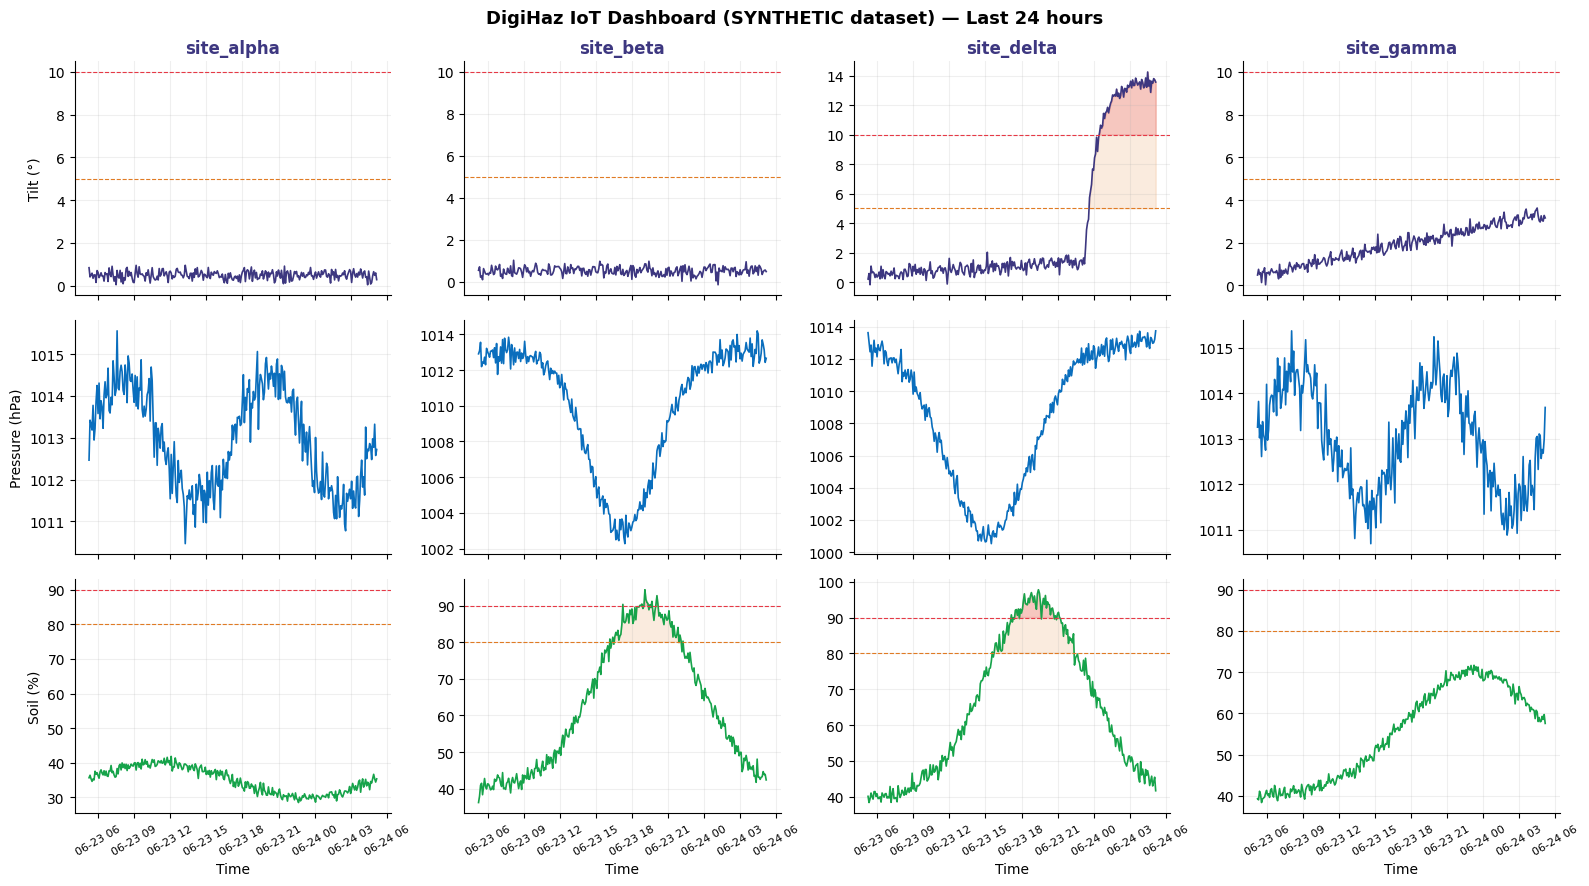

In [4]:
sites = sorted(df['site'].unique())
n_sites = len(sites)

fig, axes = plt.subplots(3, n_sites, figsize=(4*n_sites, 9), facecolor='white', sharex=True)
if n_sites == 1:
    axes = axes.reshape(3, 1)

for col, site in enumerate(sites):
    sd = df[df['site'] == site].sort_values('time')
    times = sd['time']

    axes[0,col].plot(times, sd['tilt_deg'], color=PURPLE, lw=1.2)
    axes[0,col].axhline(5, color=ORANGE, ls='--', lw=0.8)
    axes[0,col].axhline(10, color=RED, ls='--', lw=0.8)
    axes[0,col].fill_between(times, 5, sd['tilt_deg'], where=sd['tilt_deg']>5, color=ORANGE, alpha=0.15)
    axes[0,col].fill_between(times, 10, sd['tilt_deg'], where=sd['tilt_deg']>10, color=RED, alpha=0.2)
    axes[0,col].set_title(site, fontsize=12, fontweight='bold', color=PURPLE)
    if col == 0: axes[0,col].set_ylabel('Tilt (°)', fontsize=10)

    axes[1,col].plot(times, sd['press_hpa'], color=BLUE, lw=1.2)
    if col == 0: axes[1,col].set_ylabel('Pressure (hPa)', fontsize=10)

    axes[2,col].plot(times, sd['soil_pct'], color=GREEN, lw=1.2)
    axes[2,col].axhline(80, color=ORANGE, ls='--', lw=0.8)
    axes[2,col].axhline(90, color=RED, ls='--', lw=0.8)
    axes[2,col].fill_between(times, 80, sd['soil_pct'], where=sd['soil_pct']>80, color=ORANGE, alpha=0.15)
    axes[2,col].fill_between(times, 90, sd['soil_pct'], where=sd['soil_pct']>90, color=RED, alpha=0.2)
    if col == 0: axes[2,col].set_ylabel('Soil (%)', fontsize=10)
    axes[2,col].set_xlabel('Time', fontsize=10)

for ax in axes.flat:
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

source_label = 'LIVE from InfluxDB' if USE_REAL_DATA else 'SYNTHETIC dataset'
fig.suptitle(f'DigiHaz IoT Dashboard ({source_label}) — Last 24 hours',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 4 — Apply the EWS Threshold Logic

Now we apply the **same alert rules** used by the production Grafana dashboard. The rules combine evidence from multiple sensors — single-sensor thresholds would produce too many false alarms.

In [5]:
def landslide_alert(tilt_deg, soil_pct):
    if tilt_deg > 10 and soil_pct > 90: return 'RED'
    elif tilt_deg > 5 and soil_pct > 80: return 'YELLOW'
    return 'GREEN'

df['computed_alert'] = [landslide_alert(t, s) for t, s in zip(df['tilt_deg'], df['soil_pct'])]

summary = []
for site in sorted(df['site'].unique()):
    sd = df[df['site'] == site]
    first_yellow = sd[sd['computed_alert']=='YELLOW']['time'].min()
    first_red    = sd[sd['computed_alert']=='RED']['time'].min()
    summary.append({
        'Site': site,
        'First YELLOW': first_yellow.strftime('%Y-%m-%d %H:%M') if pd.notna(first_yellow) else 'never',
        'First RED':    first_red.strftime('%Y-%m-%d %H:%M')    if pd.notna(first_red)    else 'never',
        'YELLOW samples': int((sd['computed_alert']=='YELLOW').sum()),
        'RED samples':    int((sd['computed_alert']=='RED').sum()),
    })

print(pd.DataFrame(summary).to_string(index=False))

      Site First YELLOW First RED  YELLOW samples  RED samples
site_alpha        never     never               0            0
 site_beta        never     never               0            0
site_delta        never     never               0            0
site_gamma        never     never               0            0


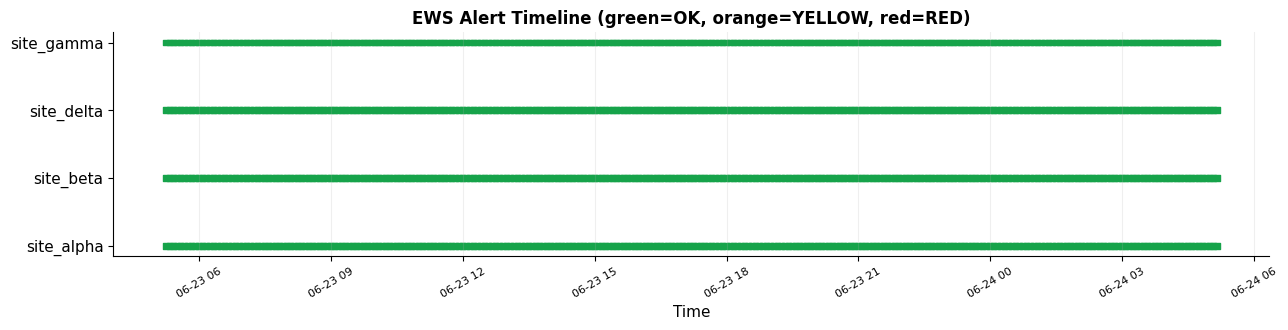

In [6]:
fig, ax = plt.subplots(figsize=(13, 1 + 0.6*n_sites), facecolor='white')
color_map = {'GREEN': GREEN, 'YELLOW': ORANGE, 'RED': RED}
for i, site in enumerate(sites):
    sd = df[df['site']==site].sort_values('time')
    colors = [color_map[a] for a in sd['computed_alert']]
    ax.scatter(sd['time'], [i]*len(sd), c=colors, s=18, marker='s')
ax.set_yticks(range(n_sites))
ax.set_yticklabels(sites, fontsize=11)
ax.set_xlabel('Time', fontsize=11)
ax.set_title('EWS Alert Timeline (green=OK, orange=YELLOW, red=RED)', fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', rotation=30, labelsize=8)
plt.tight_layout()
plt.show()

---
## Part 5 — The Real Production Dashboard

What you've built above is a static analysis. **The production dashboard** lives in Grafana Cloud and shows the same data with these enhancements:

| Feature | This notebook | Grafana dashboard |
|---------|---------------|--------------------|
| Auto-refresh | ✗ Manual re-run | ✓ Every 5 seconds |
| Multi-user access | ✗ Personal | ✓ Public URL share |
| Alert rules | ✗ Calculated only | ✓ Email/Slack on threshold cross |
| Mobile-friendly | ✗ | ✓ |
| Historical drill-down | ✗ | ✓ Click any panel for raw data |
| Persistent | ✗ Session-only | ✓ 30 days retention |

**Ask your instructor for the public dashboard URL** — it works in any browser, no accounts needed.

To set up your own: `dashboard/SETUP_DASHBOARD.md` walks you through it in ~30 minutes.

---
## 🧠 Reflection Questions

Answer in your Moodle journal:

1. The current threshold `tilt > 5° AND soil > 80%` is a **conjunction** — both conditions must be true. What would happen to the alert rate if it were a **disjunction** (`OR`)? Run the modified rule on the dataset and report the change in YELLOW samples per site.

2. The Grafana dashboard refreshes every 5 seconds. The MQTT bridge writes to InfluxDB as messages arrive (typically every 5–60 seconds depending on sensor). How much **latency** is there between a sensor reading and the Grafana panel updating? Where in the chain is the latency dominated?

3. The instructor's read-only token lets you query InfluxDB but not write to it. Why is this important for a teaching environment? What could a student with a write-token accidentally (or maliciously) do?

4. Production EWS systems use **TLS-encrypted MQTT (port 8883)** with **per-device certificates** rather than the public `test.mosquitto.org` broker. Name two specific risks the workshop setup has that a production setup would not.

---
*DigiHaz Module 7 — Notebook 3 of 3 | github.com/Digihaz/digihaz-course-materials/tree/dev/module_07_iot_sensor_networks/topic_04*